In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../dataset/cleaned_transactions.csv")

In [2]:
df.head()
df["merchant_category"].value_counts()
df["merchant_category"].nunique()

10

# Total Revenue by Merchant Category

In [3]:
merchant_revenue = (
    df.groupby("merchant_category")["amount_inr"]
      .sum()
      .reset_index()
      .sort_values("amount_inr", ascending=False)
)

merchant_revenue.head()

,merchant_category,amount_inr
7,Shopping,76863207
4,Grocery,58277893
9,Utilities,52742482
3,Fuel,38982575
0,Education,38704346


#Top Merchant Categories

In [4]:
top_categories = (
    df.groupby("merchant_category")
      .size()
      .reset_index(name="transaction_count")
      .sort_values("transaction_count", ascending=False)
)

top_categories.head(10)

,merchant_category,transaction_count
4,Grocery,49966
2,Food,37464
7,Shopping,29872
3,Fuel,25063
6,Other,24828
9,Utilities,22338
8,Transport,20105
1,Entertainment,20103
5,Healthcare,12663
0,Education,7598


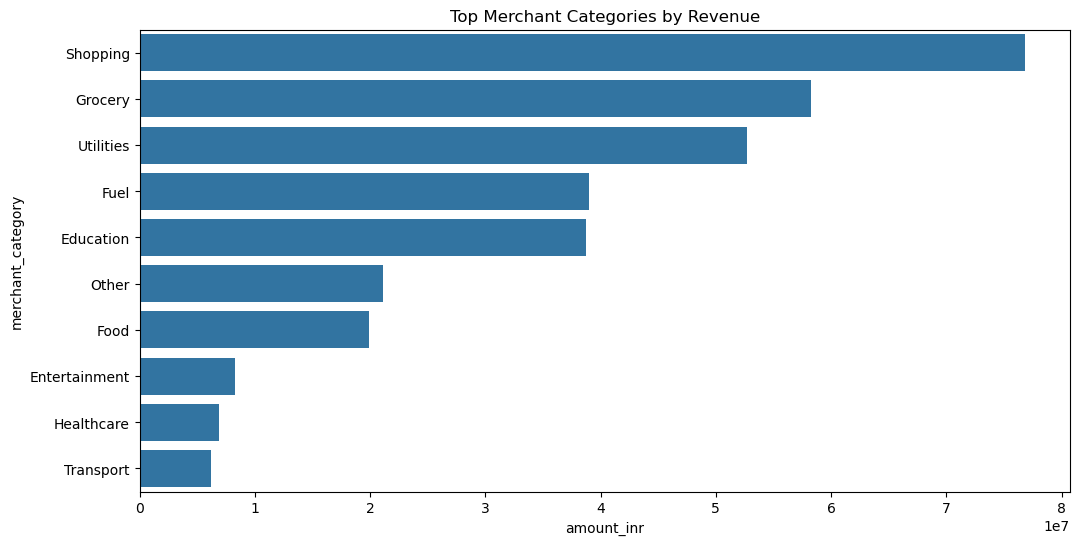

In [5]:
#Revenue Distribution
plt.figure(figsize=(12,6))

sns.barplot(
    data=merchant_revenue.head(10),
    x="amount_inr",
    y="merchant_category"
)

plt.title("Top Merchant Categories by Revenue")
plt.show()

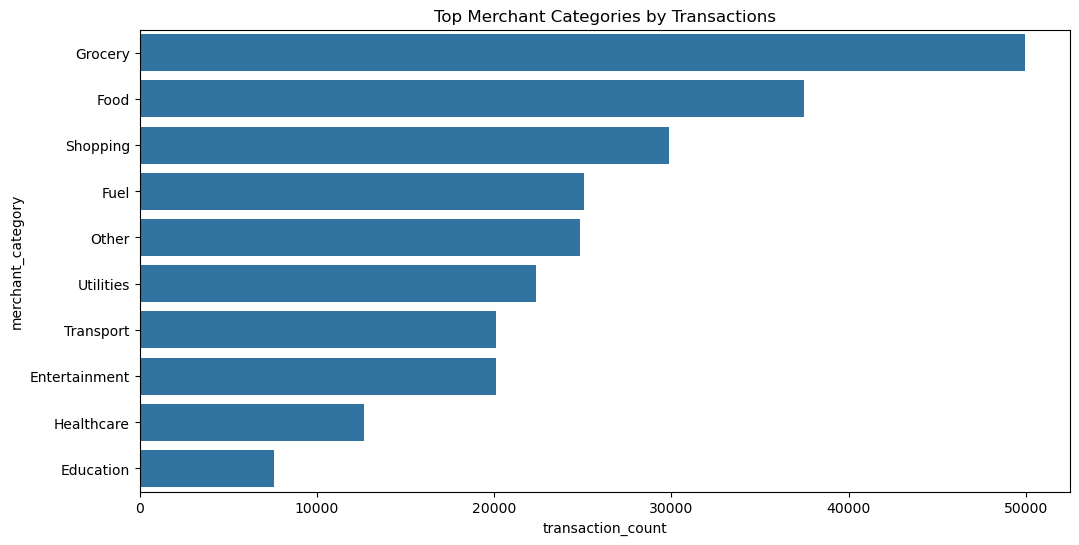

In [6]:
#Transaction Count by Category
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_categories.head(10),
    x="transaction_count",
    y="merchant_category"
)

plt.title("Top Merchant Categories by Transactions")
plt.show()

#Average Transaction Amount

In [7]:
avg_transaction = (
    df.groupby("merchant_category")["amount_inr"]
      .mean()
      .reset_index()
      .sort_values("amount_inr", ascending=False)
)

avg_transaction.head()

,merchant_category,amount_inr
0,Education,5094.017636
7,Shopping,2573.085398
9,Utilities,2361.110305
3,Fuel,1555.383434
4,Grocery,1166.350979


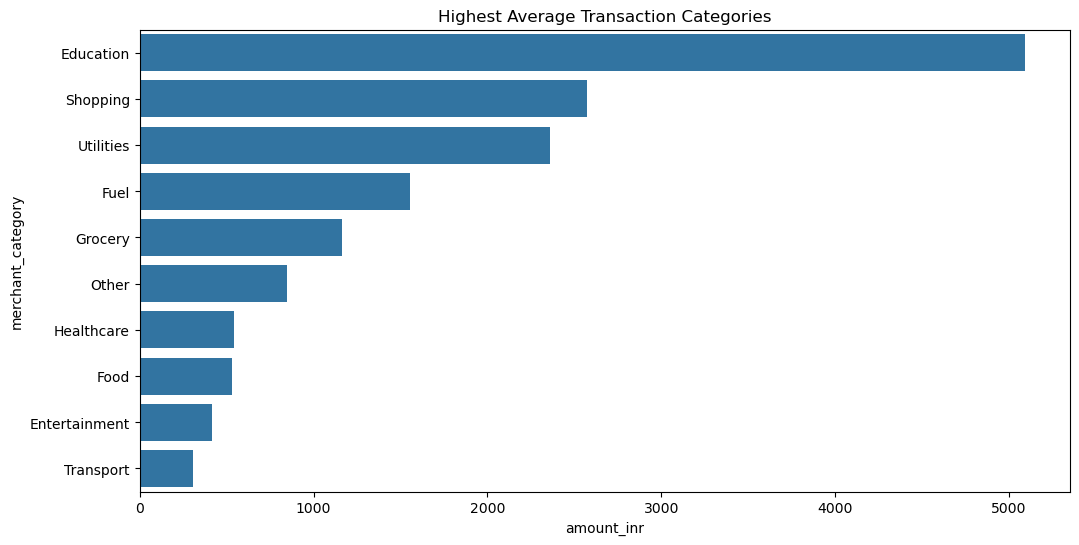

In [8]:
#Highest Ticket Merchant Categories
plt.figure(figsize=(12,6))

sns.barplot(
    data=avg_transaction.head(10),
    x="amount_inr",
    y="merchant_category"
)

plt.title("Highest Average Transaction Categories")
plt.show()

In [9]:
success_rate = (
    df.groupby("merchant_category")["transaction_status"]
      .apply(lambda x: (x=="Success").mean()*100)
      .reset_index(name="success_rate")
      .sort_values("success_rate", ascending=False)
)

success_rate.head()

,merchant_category,success_rate
0,Education,0.0
1,Entertainment,0.0
2,Food,0.0
3,Fuel,0.0
4,Grocery,0.0


In [10]:
failure_rate = (
    df.groupby("merchant_category")["transaction_status"]
      .apply(lambda x: (x=="Failed").mean()*100)
      .reset_index(name="failure_rate")
      .sort_values("failure_rate", ascending=False)
)

failure_rate.head()

,merchant_category,failure_rate
0,Education,0.0
1,Entertainment,0.0
2,Food,0.0
3,Fuel,0.0
4,Grocery,0.0


In [11]:
fraud_by_category = (
    df.groupby("merchant_category")["fraud_flag"]
      .sum()
      .reset_index()
      .sort_values("fraud_flag", ascending=False)
)

fraud_by_category.head()

,merchant_category,fraud_flag
4,Grocery,94
2,Food,73
7,Shopping,62
6,Other,50
3,Fuel,48


In [12]:
fraud_rate = (
    df.groupby("merchant_category")["fraud_flag"]
      .mean()
      .reset_index(name="fraud_rate")
)

fraud_rate["fraud_rate"] *= 100

fraud_rate.sort_values(
    "fraud_rate",
    ascending=False
).head()

,merchant_category,fraud_rate
8,Transport,0.213877
0,Education,0.210582
7,Shopping,0.207552
6,Other,0.201386
1,Entertainment,0.198975


In [13]:
weekend_analysis = (
    df.groupby(
        ["merchant_category","is_weekend"]
    )
    .size()
    .reset_index(name="transactions")
)

weekend_analysis.head()

,merchant_category,is_weekend,transactions
0,Education,0,5346
1,Education,1,2252
2,Entertainment,0,14358
3,Entertainment,1,5745
4,Food,0,26824


In [14]:
merchant_share = merchant_revenue.copy()

merchant_share["revenue_share"] = (
    merchant_share["amount_inr"] /
    merchant_share["amount_inr"].sum()
) * 100

merchant_share.head()

,merchant_category,amount_inr,revenue_share
7,Shopping,76863207,23.438263
4,Grocery,58277893,17.770955
9,Utilities,52742482,16.083016
3,Fuel,38982575,11.887142
0,Education,38704346,11.802300


In [15]:
merchant_summary = (
    df.groupby("merchant_category")
      .agg(
          transaction_count=("transaction_id","count"),
          total_revenue=("amount_inr","sum"),
          avg_transaction=("amount_inr","mean"),
          fraud_count=("fraud_flag","sum")
      )
      .reset_index()
)

merchant_summary.head()

,merchant_category,transaction_count,total_revenue,avg_transaction,fraud_count
0,Education,7598,38704346,5094.017636,16
1,Entertainment,20103,8309080,413.325374,40
2,Food,37464,19919402,531.694480,73
3,Fuel,25063,38982575,1555.383434,48
4,Grocery,49966,58277893,1166.350979,94


In [16]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df["year_month"] = (
    df["timestamp"]
      .dt.to_period("M")
)

monthly_growth = (
    df.groupby(
        ["year_month","merchant_category"]
    )
    .size()
    .reset_index(name="transactions")
)

monthly_growth.head()

,year_month,merchant_category,transactions
0,2024-01,Education,632
1,2024-01,Entertainment,1660
2,2024-01,Food,3341
3,2024-01,Fuel,2141
4,2024-01,Grocery,4208


In [17]:
#output csv
merchant_summary.to_csv(
    "../dataset/merchant_insights.csv",
    index=False
)
merchant_revenue.to_csv(
    "../dataset/merchant_revenue.csv",
    index=False
)
fraud_by_category.to_csv(
    "../dataset/merchant_fraud_analysis.csv",
    index=False
)
